# Agentic Artificial Intelligence
## Exercise - Unit 05: Integrating Tools

Welcome to the fifth unit of the Agentic Artificial Intelligence course!


## Learning Objectives
By the end of this lesson, students will:
1. Understand what tools are and why they're essential for AI agents
2. Learn how to create custom tools using the `@Tool` decorator
3. Learn how to create custom tools using the `BaseTool` class
4. Understand how to convert tools to LangChain-compatible tools
5. Learn how to integrate tools into agents using `ToolAgent`
6. Understand the graph structure for tool-using agents (conditional edges, ToolNode)
7. Understand how tool calling and execution works in LangGraph
8. Create and integrate custom tools into their own agents

## Prerequisites
- Students should have completed Unit 04 exercises on prompt templates
- Understanding of LangGraph basics (Unit 03)
- Familiarity with the `BaseAgent`, `SimpleAgent`, and `ToolAgent` classes
- Basic Python knowledge (classes, inheritance, abstract methods)

## 1. What are Tools?

**Tools** are functions or capabilities that extend an AI agent's abilities beyond just language understanding and generation. They allow agents to:

- **Perform calculations** - Mathematical operations, data processing
- **Access external data** - Web search, API calls, database queries
- **Interact with systems** - File operations, sending emails, controlling devices
- **Execute code** - Running scripts, executing commands

### Why Use Tools?

LLMs are powerful at understanding and generating text, but they have limitations:

1. **No real-time data** - LLMs are trained on historical data and can't access current information
2. **No computation** - LLMs can't reliably perform mathematical calculations
3. **No external actions** - LLMs can't interact with external systems or APIs
4. **Hallucination** - LLMs might make up information when they don't know the answer

Tools bridge these gaps by giving agents **actual capabilities** rather than just language skills.


## 2. Using the Tool Decorator

LangChain provides a convenient **`@tool` decorator** that makes it easy to create tools from Python functions. This is often the simplest way to create tools, especially for straightforward functions.

### What is the `@tool` Decorator?

The `@tool` decorator automatically converts a Python function into a LangChain tool by:
- **Extracting the function name** as the tool name
- **Using the docstring** as the tool description
- **Inferring the schema** from function type hints
- **Creating a LangChain-compatible tool** automatically

### 2.1 Creating a Tool with the Decorator

Let's create a simple tool using the decorator:

In [5]:
from langchain_core.tools import tool

@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers together.
    
    Use this tool when you need to multiply two integers.
    
    Args:
        a: The first number
        b: The second number
        
    Returns:
        The product of a and b
    """
    return a * b

# The decorator automatically creates a LangChain tool!
print("Tool created with decorator:")
print("=" * 50)
print(f"Name: {multiply.name}")
print(f"Description: {multiply.description}")
print(f"\nTesting the tool:")
print(f"multiply(5, 3) = {multiply.invoke({'a': 5, 'b': 3})}")

Tool created with decorator:
Name: multiply
Description: Multiply two numbers together.

Use this tool when you need to multiply two integers.

Args:
    a: The first number
    b: The second number

Returns:
    The product of a and b

Testing the tool:
multiply(5, 3) = 15


#### Customizing the Tool Decorator

You can customize the tool by passing arguments to the decorator:

- **Custom name**: `@tool("custom_name")` - Override the function name
- **Return direct**: `@tool(return_direct=True)` - Return tool output directly without agent processing

Let's see an example:


In [6]:
# Example: Custom tool name
@tool("power_calculator")
def power(base: float, exponent: float) -> float:
    """Calculate base raised to the power of exponent.
    
    Use this tool for exponentiation operations.
    
    Args:
        base: The base number
        exponent: The exponent (power)
        
    Returns:
        base raised to the power of exponent
    """
    return base ** exponent

print("Custom named tool:")
print("=" * 50)
print(f"Name: {power.name}")
print(f"Description: {power.description[:80]}...")
print(f"\nTesting: power(2, 8) = {power.invoke({'base': 2, 'exponent': 8})}")


Custom named tool:
Name: power_calculator
Description: Calculate base raised to the power of exponent.

Use this tool for exponentiatio...

Testing: power(2, 8) = 256.0


In [7]:
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, ToolMessage


llm = init_chat_model("gemini-2.5-flash-lite", model_provider="google_genai")
llm_with_tools = llm.bind_tools([power, multiply])

query = HumanMessage(content="What is 2 to the power of 8? Provide the result in a sentence.")
ai_msg = llm_with_tools.invoke([query])

# Check the tool calls in the response
print(ai_msg.tool_calls)

[{'name': 'power_calculator', 'args': {'exponent': 8.0, 'base': 2.0}, 'id': '77015a17-e1e3-4cb0-a274-dde0cccec8d2', 'type': 'tool_call'}]


In [8]:
# If the llm actually ran a tool we would need to pass its response back into the llm
tool_message = ToolMessage(
    content=power(ai_msg.tool_calls[0]["args"]),
    tool_call_id=ai_msg.tool_calls[0]["id"],
)

full_conversation = [query, ai_msg, tool_message]

final_response = llm_with_tools.invoke(full_conversation)
final_response.pretty_print()

/var/folders/s9/b3fxxrts6ld4cqfnyln1m3hr0000gn/T/ipykernel_25861/1545733765.py:3: LangChainDeprecationWarning: The method `BaseTool.__call__` was deprecated in langchain-core 0.1.47 and will be removed in 1.0. Use :meth:`~invoke` instead.
  content=power(ai_msg.tool_calls[0]["args"]),


================================== Ai Message ==================================

2 to the power of 8 is 256.


### 2.2 Creating a Tool with the langchain's `BaseTool` class (by subclassing)

Let's create a simple tool using langchain's `BaseTool` class:

In [9]:
from langchain_core.tools import BaseTool

class PowerTool(BaseTool):
    name: str = "power_calculator"
    description: str = """Calculate base raised to the power of exponent.
    
    Use this tool for exponentiation operations.
    
    Args:
        base: The base number
        exponent: The exponent (power)
        
    Returns:
        base raised to the power of exponent
    """
    
    def _run(self, base: float, exponent: float) -> float:
        return base ** exponent
    

tools = [PowerTool()]

llm_with_tools = llm.bind_tools(tools)

query = HumanMessage(content="What is 2 to the power of 8?")
ai_msg = llm_with_tools.invoke([query])

print(ai_msg.tool_calls)

[{'name': 'power_calculator', 'args': {'exponent': 8.0, 'base': 2.0}, 'id': '48f92051-c224-439a-9047-bba98b8eb30d', 'type': 'tool_call'}]


### 2.3 Using tools implementd in our package

Let's start by exploring the tools that are already available in the codebase:

In [11]:
import sys
import os

# Get the path to the root of the project (two levels up from exercises/unit_01)
# Current dir is exercises/unit_01, so we need to go up 2 levels
current_dir = os.path.abspath(os.getcwd())
project_root = os.path.abspath(os.path.join(current_dir, '..', '..'))

# Ensure the root folder is the first place Python looks for modules
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Check the path list for verification
print(f"Project root added to sys.path: {project_root}")
print(f"Current working directory: {current_dir}")

# Also verify agentic_ai can be imported
try:
    import agentic_ai
    print(f"✅ agentic_ai imported successfully from: {agentic_ai.__file__}")
except ImportError as e:
    print(f"❌ Failed to import agentic_ai: {e}")
    print(f"Python path: {sys.path[:3]}")

Project root added to sys.path: /Users/linaquick/Desktop/Agentic AI/agentic_artificial_intelligence
Current working directory: /Users/linaquick/Desktop/Agentic AI/agentic_artificial_intelligence/exercises/unit_05
✅ agentic_ai imported successfully from: /Users/linaquick/Desktop/Agentic AI/agentic_artificial_intelligence/agentic_ai/__init__.py


In [12]:
# Import the tools module
from agentic_ai.tools import CalculatorTool

# Create an instance of the calculator tool
calc = CalculatorTool()

print("Tool Information:")
print(f"Name: {calc.name}")
print(f"Description: {calc.description}")
print(f"\nTool String Representation: {calc}")

Tool Information:
Name: calculator
Description: 
            Perform basic mathematical calculations. Supports +, -, *, /, ** (power), and parentheses. Example: '2 + 3 * 4'
            
            Args:
                expression: Mathematical expression as a string
                
            Returns:
                Result of the calculation or error message
            

Tool String Representation: name='calculator' description="\n            Perform basic mathematical calculations. Supports +, -, *, /, ** (power), and parentheses. Example: '2 + 3 * 4'\n            \n            Args:\n                expression: Mathematical expression as a string\n                \n            Returns:\n                Result of the calculation or error message\n            "


### Testing the Calculator Tool in a llm call

In [14]:
llm_with_tools = llm.bind_tools([CalculatorTool()])

query = HumanMessage(content="What is 2 to the power of 8?")
ai_msg = llm_with_tools.invoke([query])

print(ai_msg.tool_calls)

tool_message = ToolMessage(
    content=CalculatorTool().run(ai_msg.tool_calls[0]["args"]),
    tool_call_id=ai_msg.tool_calls[0]["id"],
)

final_response = llm_with_tools.invoke([query, ai_msg, tool_message])
print(final_response)

[{'name': 'calculator', 'args': {'expression': '2**8'}, 'id': '3d5f3728-def1-4618-b78a-62011bb7329b', 'type': 'tool_call'}]
content='' additional_kwargs={} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []} id='run--87a75e27-61c7-47ca-896c-b15e93b91413-0' usage_metadata={'input_tokens': 134, 'output_tokens': 0, 'total_tokens': 134, 'input_token_details': {'cache_read': 0}}


### When to Use the Decorator vs. BaseTool

**Use the `@tool` decorator when:**
- ✅ You have a simple function that can be converted directly
- ✅ You want quick, straightforward tool creation
- ✅ The function signature clearly describes what the tool does
- ✅ You don't need complex initialization or state management

**Use `BaseTool` class when:**
- ✅ You need more control over tool creation
- ✅ You want to organize tools in a class hierarchy
- ✅ You need to manage tool state or configuration
- ✅ You want to create reusable tool classes

**Note:** Both approaches create LangChain-compatible tools that work with agents!


### Key Components of a Tool

1. **Name** - A unique identifier for the tool
2. **Description** - A clear description that helps the LLM understand when to use the tool
3. **_run() method** - The actual implementation that executes the tool

The description is **crucial** - it's what the LLM reads to decide whether to use the tool!

## 3. Implementing a ToolAgent

Now let's see how tools are integrated into actual agents (not just making llm calls). So far we only worked with a simple agent that does not use tools and does not implement the Thought-Action-Observation cycle.

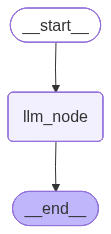

In [15]:
from agentic_ai.agents.simple_agent import SimpleAgent

llm = init_chat_model("gemini-2.5-flash-lite", model_provider="google_genai")

SimpleAgent(llm, 'simple_agent').graph

The `ToolAgent` class implements the Thought-Action-Observation / ReAct idea.

### 3.1 Understanding the Tool Agent Graph Structure

The `ToolAgent` uses a special graph structure to handle tool calling. Let's visualize it:

```
┌─────────┐
│  START  │
└────┬────┘
     │
     ▼
┌─────────┐
│  agent  │  (LLM decides: use tool or respond)
└────┬────┘
     │
     ├─── Conditional Edge ───┐
     │                        │
     ▼                        ▼
┌─────────┐              ┌─────────┐
│  tools  │              │   END   │
└────┬────┘              └─────────┘
     │
     │ (after tool execution)
     │
     └───► back to agent ───┐
                            │
                            ▼
                       (loop until done)
```

### Key Components:

1. **Agent Node** - The LLM processes messages and decides whether to call tools
2. **Conditional Edge** - Routes to tools if tool calls are needed, or END if done
3. **Tool Node** - Executes the requested tools
4. **Loop Back** - After tools execute, control returns to the agent node

This creates a **loop** where the agent can call tools multiple times until it has enough information to respond.

### 3.2 Examining the ToolAgent Implementation

Let's look at how the conditional routing works:

In [16]:
import sys, importlib.util
print(sys.executable)
print(importlib.util.find_spec("agentic_ai"))

/Users/linaquick/Desktop/Agentic AI/agentic_artificial_intelligence/.venv/bin/python
ModuleSpec(name='agentic_ai', loader=<_frozen_importlib_external.SourceFileLoader object at 0x112289bb0>, origin='/Users/linaquick/Desktop/Agentic AI/agentic_artificial_intelligence/agentic_ai/__init__.py', submodule_search_locations=['/Users/linaquick/Desktop/Agentic AI/agentic_artificial_intelligence/agentic_ai'])


In [17]:
# Import necessary classes
from agentic_ai.agents.tool_agent import ToolAgent
from langchain.chat_models import init_chat_model
from langgraph.checkpoint.memory import InMemorySaver

# Initialize LLM
llm = init_chat_model("gemini-2.5-flash-lite", model_provider="google_genai")
memory = InMemorySaver()

# Create tools
calculator_tool = CalculatorTool()

# Convert to LangChain tools
langchain_tools = [
    calculator_tool#.to_langchain_tool()
]

# Create agent with tools
agent = ToolAgent(
    llm=llm,
    tools=langchain_tools,
    name="MathBot",
    checkpointer=memory
)

print("Agent created with tools:")
print("=" * 50)
for tool_name in agent.get_available_tools():
    print(f"  - {tool_name}")

Agent created with tools:
  - calculator


ToolAgent Graph Structure:


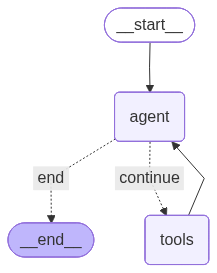

In [18]:
# Let's examine the graph structure
print("ToolAgent Graph Structure:")
print("=" * 50)
agent.graph

### 3.3 Testing the ToolAgent

Let's instantiate the ToolAgent and test the agent with questions that require tool usage:

In [19]:
print("\n\nTest: Complex calculation")
print("=" * 50)
response = agent.run("Calculate (10 + 5) * 3 - 7", thread_id="test")
response['messages'][-1].pretty_print()



Test: Complex calculation
================================== Ai Message ==================================

The result of the calculation (10 + 5) * 3 - 7 is 38.


The result is corrent, but we actually do not know if the agent used the tool or not.

In [20]:
from langchain_core.messages import AIMessage

# # test if agent used the tool
for msg in response['messages']:
    if isinstance(msg, AIMessage) and msg.tool_calls:
        print('The agent used the tool with the following message:')
        print(msg)

The agent used the tool with the following message:
content='' additional_kwargs={'function_call': {'name': 'calculator', 'arguments': '{"expression": "(10 + 5) * 3 - 7"}'}} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []} id='run--b16391ff-25ec-4b0b-9718-aaca38824e4a-0' tool_calls=[{'name': 'calculator', 'args': {'expression': '(10 + 5) * 3 - 7'}, 'id': '451a2dda-36b9-4643-9bbe-917b5118ee93', 'type': 'tool_call'}] usage_metadata={'input_tokens': 152, 'output_tokens': 24, 'total_tokens': 176, 'input_token_details': {'cache_read': 0}}


### 3.4 Understanding Tool Calling Flow

When an agent uses tools, here's what happens:

1. **User sends message** - "What is 25 * 4?"
2. **Agent node processes** - LLM sees the question and decides it needs the calculator tool
3. **LLM generates tool call** - Creates a special message requesting the calculator tool
4. **Conditional edge routes to tools** - Graph detects tool calls and routes to tool node
5. **Tool node executes** - Calculator tool runs with "25 * 4"
6. **Tool result added** - Result (100) is added to the conversation
7. **Control returns to agent** - Agent node processes again with the tool result
8. **Agent responds** - LLM generates final answer: "25 multiplied by 4 equals 100"
9. **Conditional edge routes to END** - No more tool calls, conversation ends

Let's trace through a conversation to see this in action:

In [21]:
# Let's see the full conversation history after a tool call
response = agent.run("What is 15 * 7?", thread_id="trace_example")

print("Full Conversation History:")
print("=" * 50)
history = agent.get_conversation_history(thread_id="trace_example")

for i, msg in enumerate(history):
    print(f"\n{i+1}. {msg.__class__.__name__}:")
    if hasattr(msg, 'tool_calls') and msg.tool_calls:
        print(f"   Tool Calls: {msg.tool_calls}")
    if hasattr(msg, 'tool_call_id'):
        print(f"   Tool Call ID: {msg.tool_call_id}")
    print(f"   Content: {str(msg.content)[:200]}..." if len(str(msg.content)) > 200 else f"   Content: {msg.content}")


Full Conversation History:

1. SystemMessage:
   Content: You are a helpful AI assistant with access to various tools. Use the available tools when they can help answer the user's question or complete their request. Always explain what you're doing and provi...

2. HumanMessage:
   Content: What is 15 * 7?

3. AIMessage:
   Tool Calls: [{'name': 'calculator', 'args': {'expression': '15 * 7'}, 'id': '2876943b-3c17-44bf-8a11-5ee03be98702', 'type': 'tool_call'}]
   Content: 

4. ToolMessage:
   Tool Call ID: 2876943b-3c17-44bf-8a11-5ee03be98702
   Content: 105

5. AIMessage:
   Content: 15 * 7 is 105.


## Summary: Tool Integration

**Key Takeaways:**

1. **Tools extend agent capabilities** - They allow agents to perform actions beyond language
2. **Two ways to create tools:**
   - **`@tool` decorator** - Quick and simple for functions
   - **`BaseTool` class** - More control and organization
3. **Tool descriptions are crucial** - LLMs use them to decide when to use tools
4. **Tools must be bound to LLM** - Use `llm.bind_tools()` to make tools available
5. **ToolAgent uses conditional edges** - Routes between agent and tool nodes
6. **Tool execution creates a loop** - Agent → Tools → Agent → ... → End

**Pattern 1: Using the `@tool` Decorator (Simplest)**
```python
from langchain_core.tools import tool

@tool
def my_tool(input: str) -> str:
    """Tool description here."""
    return result

# Use directly - no conversion needed!
agent = ToolAgent(llm, tools=[my_tool])
```

**Pattern 2: Using `BaseTool` Class (More Control)**
```python
# 1. Create tools
tool = MyCustomTool()

# 2. Convert to LangChain format
langchain_tool = tool.to_langchain_tool()

# 3. Bind to LLM
llm_with_tools = llm.bind_tools([langchain_tool])

# 4. Create agent
agent = ToolAgent(llm_with_tools, tools=[langchain_tool])
```

Now you're ready to create and integrate your own tools!

# Exercise

In this exercise, you will create custom tools and integrate them into an agent, demonstrating your understanding of tool creation, LangChain integration, and agent architecture.

## Task 1: Create a Custom Tool

Create a new tool class called `TextLengthTool` that:

1. **Inherits from `BaseTool`**
2. **Takes a text string as input**
3. **Returns the length of the text** (number of characters, number of words, number of sentrences)
4. **Has a clear, descriptive description** that explains when to use it
5. **Implements both `run()` and `to_langchain_tool()` methods**

**Requirements:**
- Tool name should be `"text_length"`
- Description should clearly explain the tool's purpose and when to use it
- Handle edge cases (empty strings, None values)
- Test your tool with various inputs

**Hints:**
- Review the `CalculatorTool` example
- Use `len()` to get string length
- Return a clear error message if input is invalid

### Task 1.1: Implement Your TextLengthTool

Create your tool class below:

In [ ]:
# TODO: Create your TextLengthTool class here

# Test your tool
# tool = TextLengthTool()
# print(tool.run("Hello, World!"))
# print(tool.run(""))
# print(tool.run("This is a longer text string."))


In [ ]:
from agentic_ai.tools import TextLengthTool

ImportError: cannot import name 'TextLengthTool' from 'agentic_ai.tools' (/Users/linaquick/Desktop/Agentic AI/agentic_artificial_intelligence/agentic_ai/tools/__init__.py)

## Task 2: Integrate Tools into an Agent

Create a `ToolAgent` instance that uses both your custom tools (`TextLengthTool`) plus the `CalculatorTool`:

1. **Create instances of all three tools**
2. **Convert them to LangChain tools**
3. **Create a ToolAgent with these tools**
4. **Test the agent with various queries**

**Test Cases:**
- "What is the length of the text 'Hello, World!'?"
- "How many words are in 'This is a test sentence'?"
- "Calculate 15 * 7"
- "What is the length and word count of 'Agentic AI is fascinating'?"
- "Write a poem about agentic AI that is exactly 7 sentences long"

**Expected behavior:**
- Agent should use the appropriate tool(s) for each query
- Agent should provide clear, helpful responses
- Agent should handle multiple tool calls in a single query

In [ ]:
# TODO: Integrate your tools into a ToolAgent

# from agentic_ai.agents.tool_agent import ToolAgent
# from agentic_ai.tools import CalculatorTool
# from langchain.chat_models import init_chat_model
# from langgraph.checkpoint.memory import InMemorySaver

# # Initialize LLM and memory
# llm = init_chat_model("gemini-2.5-flash-lite", model_provider="google_genai")
# memory = InMemorySaver()

# # Create tools
# # TODO: Create instances of TextLengthTool, CalculatorTool

# # Convert to LangChain tools
# # TODO: Convert all tools to LangChain format

# # Create agent
# # TODO: Create ToolAgent with the tools

# # Test the agent
# # TODO: Test with the test cases listed above

## Task 3: Examine Tool Calling Behavior

After testing your agent, examine the conversation history to understand how tool calling works:

1. **Print the full conversation history** for one of your test queries
2. **Identify tool call messages** - Look for messages with `tool_calls` attribute
3. **Identify tool result messages** - Look for messages with `tool_call_id` attribute
4. **Trace the flow** - Understand how the agent → tool → agent loop works

**Questions to answer:**
- How many messages are in the conversation?
- Which messages contain tool calls?
- Which messages are tool results?
- What is the final AI response?

In [ ]:
# TODO: Examine conversation history

# # Get conversation history
# history = agent.get_conversation_history(thread_id="your_thread_id")

# # Print detailed information about each message
# for i, msg in enumerate(history):
#     print(f"\n{i+1}. {msg.__class__.__name__}:")
#     # TODO: Check for tool_calls
#     # TODO: Check for tool_call_id
#     # TODO: Print message content

## Task 4 (Bonus): Create a More Complex Tool

Create a `TextAnalysisTool` that:

1. **Takes a text string as input**
2. **Returns multiple statistics:**
   - Character count (with and without spaces)
   - Word count
   - Sentence count (split by periods, exclamation marks, question marks)
   - Average words per sentence
3. **Returns results in a formatted string**

**Requirements:**
- Handle edge cases (empty text, no sentences, etc.)
- Provide clear, readable output
- Use your existing tools internally if helpful

**Example output:**
```
Text Analysis Results:
- Characters (with spaces): 45
- Characters (without spaces): 38
- Words: 8
- Sentences: 2
- Average words per sentence: 4.0
```

In [ ]:
# TODO: Create your TextAnalysisTool class here

# Test your tool
# tool = TextAnalysisTool()
# print(tool.run("Hello world. This is a test!"))

## Task 6 (Advanced Bonus): Build a Custom Tool-Using Agent

Create your own agent class that extends `BaseAgent` and implements tool calling similar to `ToolAgent`, but with custom behavior:

1. **Create a class called `CustomToolAgent`** that extends `BaseAgent`
2. **Implement tool calling logic** similar to `ToolAgent`
3. **Add a preprocessing node** that logs tool usage
4. **Add custom logic** - e.g., limit the number of tool calls per conversation

**Requirements:**
- Use conditional edges for tool routing
- Implement `should_continue()` method
- Add a tool call counter to prevent infinite loops
- Log each tool call with a print statement

**Hints:**
- Review `ToolAgent` implementation
- Use `ToolNode` from `langgraph.prebuilt`
- Add a `max_tool_calls` parameter to limit iterations
- Track tool calls in the state or as an instance variable

In [ ]:
# TODO: Create your CustomToolAgent class here

from agentic_ai.agents.base import BaseAgent, State
# from langgraph.graph import StateGraph, END
# from langgraph.prebuilt import ToolNode
# from typing import List
# from langchain_core.tools import BaseTool

# class CustomToolAgent(BaseAgent):
#     def __init__(self, llm, tools: List[BaseTool], name="CustomToolAgent", max_tool_calls=5, **kwargs):
#         # TODO: Initialize with tools and max_tool_calls
#         pass
#     
#     def _build_graph(self):
#         # TODO: Build graph with tool calling logic
#         pass
#     
#     def call_model(self, state: State) -> State:
#         # TODO: Call LLM and handle tool calls
#         pass
#     
#     def should_continue(self, state: State) -> str:
#         # TODO: Check if should continue with tools or end
#         # TODO: Check max_tool_calls limit
#         pass
#     
#     def log_tool_usage(self, state: State):
#         # TODO: Log tool usage
#         pass

---

## Submission Checklist

- [ ] `TextLengthTool` class created and inherits from `BaseTool`
- [ ] `TextLengthTool` implements `run()` and `to_langchain_tool()` methods
- [ ] `TextLengthTool` has a clear, descriptive description
- [ ] `ToolAgent` created with all three tools (TextLength, Calculator)
- [ ] Agent successfully uses tools for various queries
- [ ] Conversation history examined and tool calling flow understood
- [ ] (Bonus) `TextAnalysisTool` created with multiple statistics
- [ ] (Advanced Bonus) `CustomToolAgent` created with custom tool calling logic

## Key Learning Points

After completing this exercise, you should understand:

1. ✅ How to create custom tools by extending `BaseTool`
2. ✅ How to implement the `run()` method for tool execution
3. ✅ How to convert tools to LangChain format using `to_langchain_tool()`
4. ✅ How to bind tools to LLMs using `llm.bind_tools()`
5. ✅ How to integrate tools into agents using `ToolAgent`
6. ✅ How conditional edges route between agent and tool nodes
7. ✅ How tool calling creates a loop: Agent → Tools → Agent → End
8. ✅ How tool descriptions help LLMs decide when to use tools
9. ✅ How to examine conversation history to understand tool execution flow